In [10]:
import kagglehub
path = kagglehub.dataset_download("therohithanand/used-car-price-prediction")

Using Colab cache for faster access to the 'used-car-price-prediction' dataset.


In [11]:
!ls /root/.cache/kagglehub/datasets/therohithanand/used-car-price-prediction/versions/1

used_car_price_dataset_extended.csv


In [12]:
import os
os.listdir("/kaggle/input")

['used-car-price-prediction']

In [13]:
import pandas as pd

In [14]:
df = pd.read_csv("/kaggle/input/used-car-price-prediction/used_car_price_dataset_extended.csv")
df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


In [15]:
df.shape

(10000, 12)

In [16]:
df.columns

Index(['make_year', 'mileage_kmpl', 'engine_cc', 'fuel_type', 'owner_count',
       'price_usd', 'brand', 'transmission', 'color', 'service_history',
       'accidents_reported', 'insurance_valid'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


In [18]:
df.describe()

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2009.206900,17.960753,2287.130000,3.003500,7179.754532,0.492200
std,8.373858,5.025486,1291.276927,1.418904,2795.270940,0.694109
min,1995.000000,5.000000,800.000000,1.000000,1000.000000,0.000000
25%,2002.000000,14.540000,1200.000000,2.000000,5176.547500,0.000000
50%,2009.000000,17.970000,1800.000000,3.000000,6961.260000,0.000000
75%,2016.000000,21.352500,3000.000000,4.000000,8993.732500,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,17647.630000,5.000000


In [19]:
df.isnull().sum()

,0
make_year,0
mileage_kmpl,0
engine_cc,0
fuel_type,0
owner_count,0
price_usd,0
brand,0
transmission,0
color,0
service_history,2038


In [20]:
df["service_history"].value_counts(dropna=False)

,count
service_history,
Full,4987
Partial,2975
NaN,2038


In [21]:
df["service_history"] = df["service_history"].fillna("Unknown")

In [22]:
df.describe(include="object")

,fuel_type,brand,transmission,color,service_history,insurance_valid
count,10000,10000,10000,10000,10000,10000
unique,3,10,2,6,3,2
top,Petrol,Nissan,Manual,Gray,Full,Yes
freq,4968,1089,5985,1705,4987,7934


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


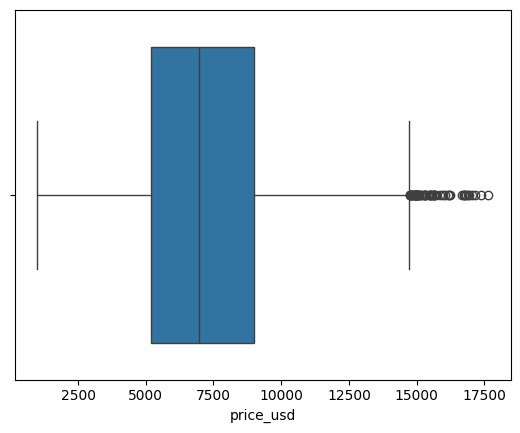

In [25]:
sns.boxplot(x=df["price_usd"])
plt.show()

In [26]:
Q1 = df["price_usd"].quantile(0.25)
Q3 = df["price_usd"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["price_usd"] < lower) | (df["price_usd"] > upper)]
print("Number of Outliers:", len(outliers))

Number of Outliers: 58


In [28]:
for col in ["fuel_type", "brand", "transmission", "color",
            "service_history", "insurance_valid"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


fuel_type
fuel_type
Petrol      4968
Diesel      4058
Electric     974
Name: count, dtype: int64

brand
brand
Nissan        1089
Volkswagen    1033
BMW           1021
Tesla         1006
Honda         1003
Chevrolet      999
Hyundai        989
Toyota         956
Kia            955
Ford           949
Name: count, dtype: int64

transmission
transmission
Manual       5985
Automatic    4015
Name: count, dtype: int64

color
color
Gray      1705
Black     1702
Red       1678
White     1651
Blue      1634
Silver    1630
Name: count, dtype: int64

service_history
service_history
Full       4987
Partial    2975
Unknown    2038
Name: count, dtype: int64

insurance_valid
insurance_valid
Yes    7934
No     2066
Name: count, dtype: int64


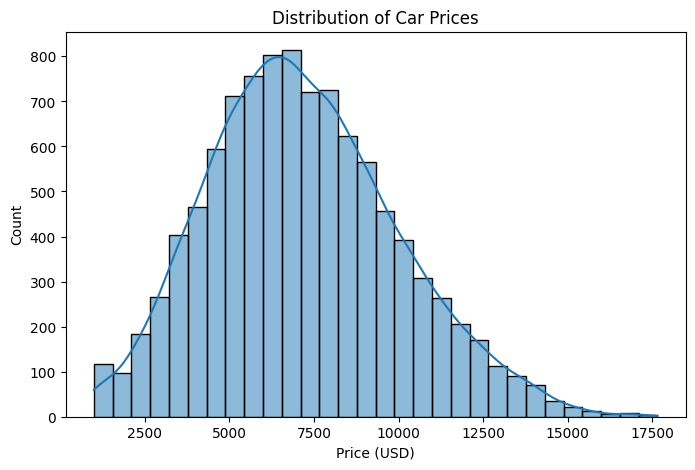

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df["price_usd"], bins=30, kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")

plt.show()

#• معظم أسعار السيارات تقع بين 5000 و9000 دولار.
#• توزيع الأسعار منحرف ناحية اليمين
#(Right Skewed).
#• يوجد عدد قليل من السيارات ذات الأسعار المرتفعة.
#• البيانات ليست موزعة توزيعًا طبيعيًا.

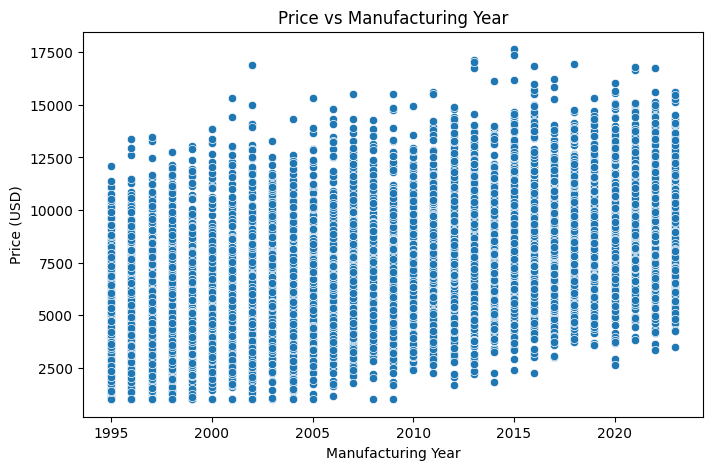

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="make_year",
    y="price_usd"
)

plt.title("Price vs Manufacturing Year")
plt.xlabel("Manufacturing Year")
plt.ylabel("Price (USD)")

plt.show()

Observation:

• توجد علاقة موجبة بين سنة تصنيع السيارة وسعرها.
• بشكل عام، السيارات الأحدث تكون أعلى سعرًا من السيارات الأقدم.
• العلاقة ليست خطية تمامًا، حيث يوجد تشتت في الأسعار داخل كل سنة تصنيع.
• يشير هذا التشتت إلى أن السعر يتأثر بعوامل أخرى بجانب سنة التصنيع.
• يعتبر make_year Feature مهمة ومن المتوقع أن تساعد نموذج التنبؤ بالسعر.

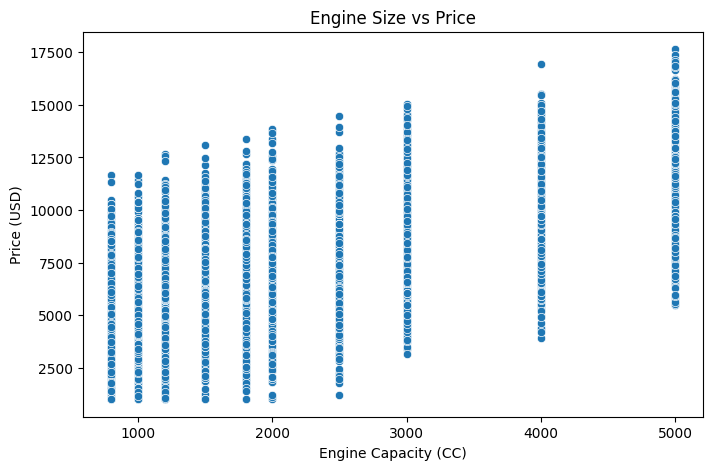

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="engine_cc",
    y="price_usd"
)

plt.title("Engine Size vs Price")
plt.xlabel("Engine Capacity (CC)")
plt.ylabel("Price (USD)")

plt.show()

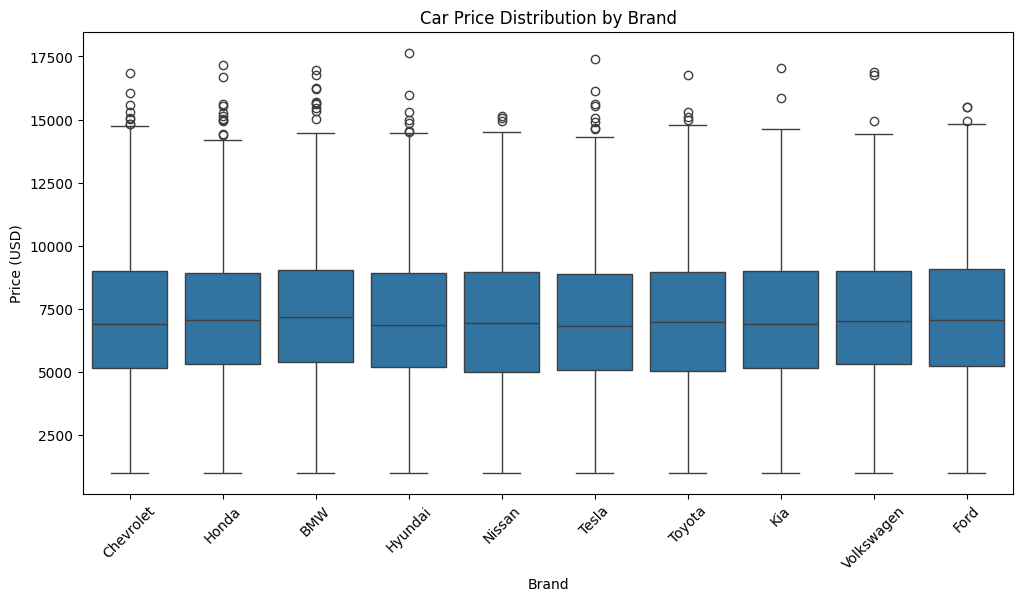

In [36]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="brand",
    y="price_usd"
)

plt.title("Car Price Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)

plt.show()

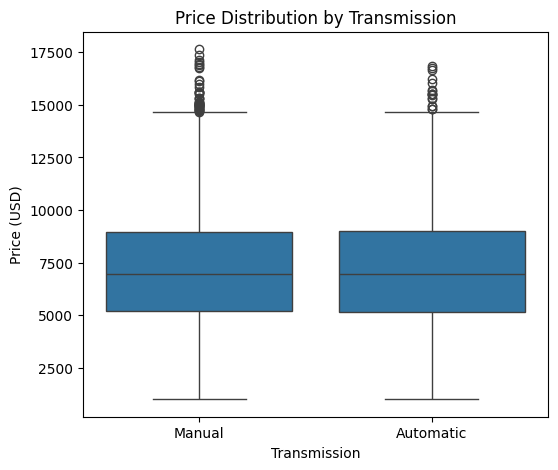

In [37]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="transmission",
    y="price_usd"
)

plt.title("Price Distribution by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Price (USD)")

plt.show()

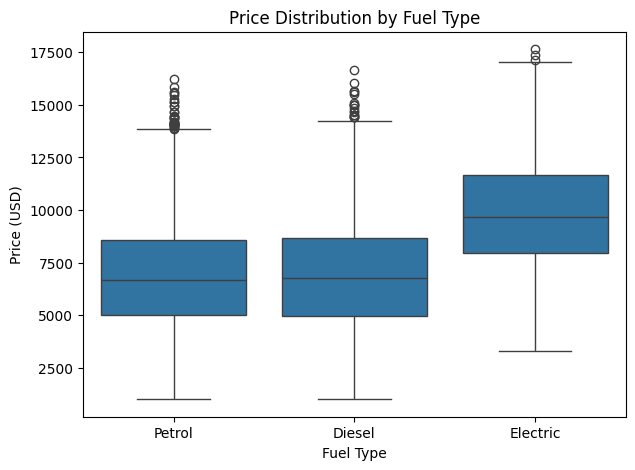

In [38]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="fuel_type",
    y="price_usd"
)

plt.title("Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (USD)")

plt.show()

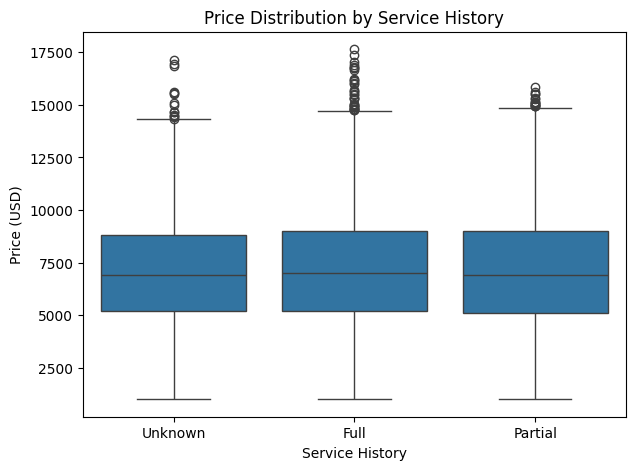

In [39]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="service_history",
    y="price_usd"
)

plt.title("Price Distribution by Service History")
plt.xlabel("Service History")
plt.ylabel("Price (USD)")

plt.show()

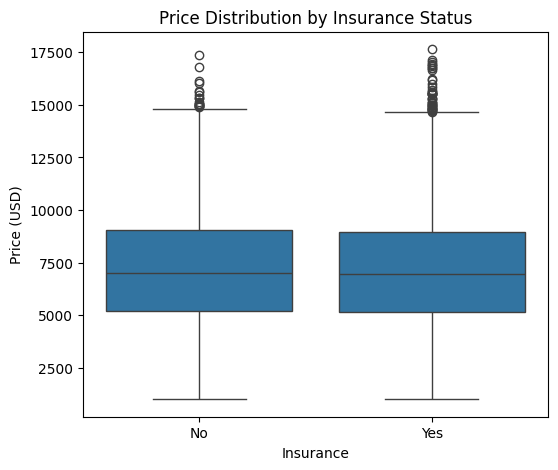

In [40]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="insurance_valid",
    y="price_usd"
)

plt.title("Price Distribution by Insurance Status")
plt.xlabel("Insurance")
plt.ylabel("Price (USD)")

plt.show()

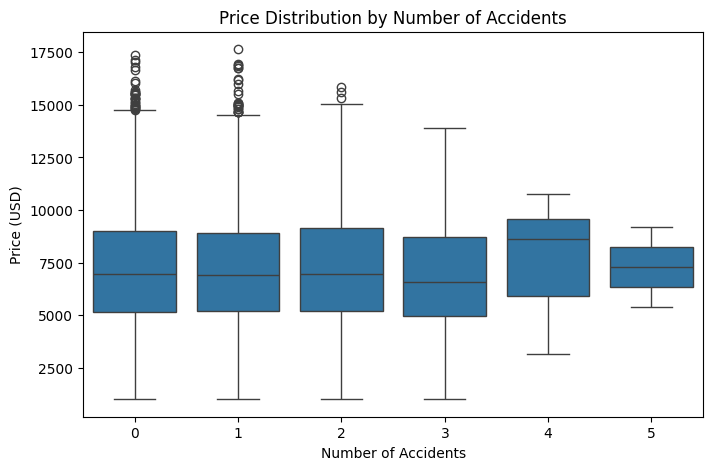

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="accidents_reported",
    y="price_usd"
)

plt.title("Price Distribution by Number of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Price (USD)")

plt.show()

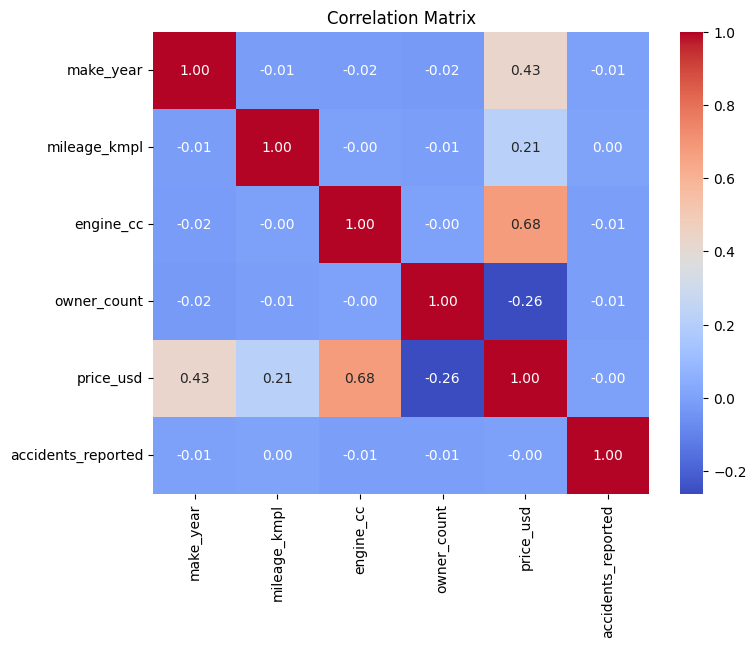

In [42]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [43]:
# Save Cleaned Dataset
df.to_csv("used_car_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
